<a href="https://colab.research.google.com/github/Ghadah-6/All-Image-Processing-labs/blob/main/Lab3_Image_Mnupilations_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [25]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data
import math

In [9]:
# ── Load image ────────────────────────────────────
img = Image.open("/content/AD.jpg")

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [10]:
# Get the size of the image
width, height = img.size
print(f"true size: {width} x {height}")
# scaling factors
x = 2
y = 2

true size: 1000 x 1000


In [11]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * x)
new_height = int(height * y)
# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)

In [12]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"true size: {img.size}")
print(f"Scaled size: {scaled_img.size}")

true size: (1000, 1000)
Scaled size: (2000, 2000)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [13]:
cx = 2
cy = 1
new_width_nu = int(width * cx)
new_height_nu = int(height * cy)

In [14]:
nonuniform_scaled_img = img.resize((new_width_nu, new_height_nu), Image.LANCZOS)

In [15]:
nonuniform_scaled_img.save("task1_1b_nonuniform_scaled.jpg")

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (1000, 1000)
Rotated size: (1368, 1368)


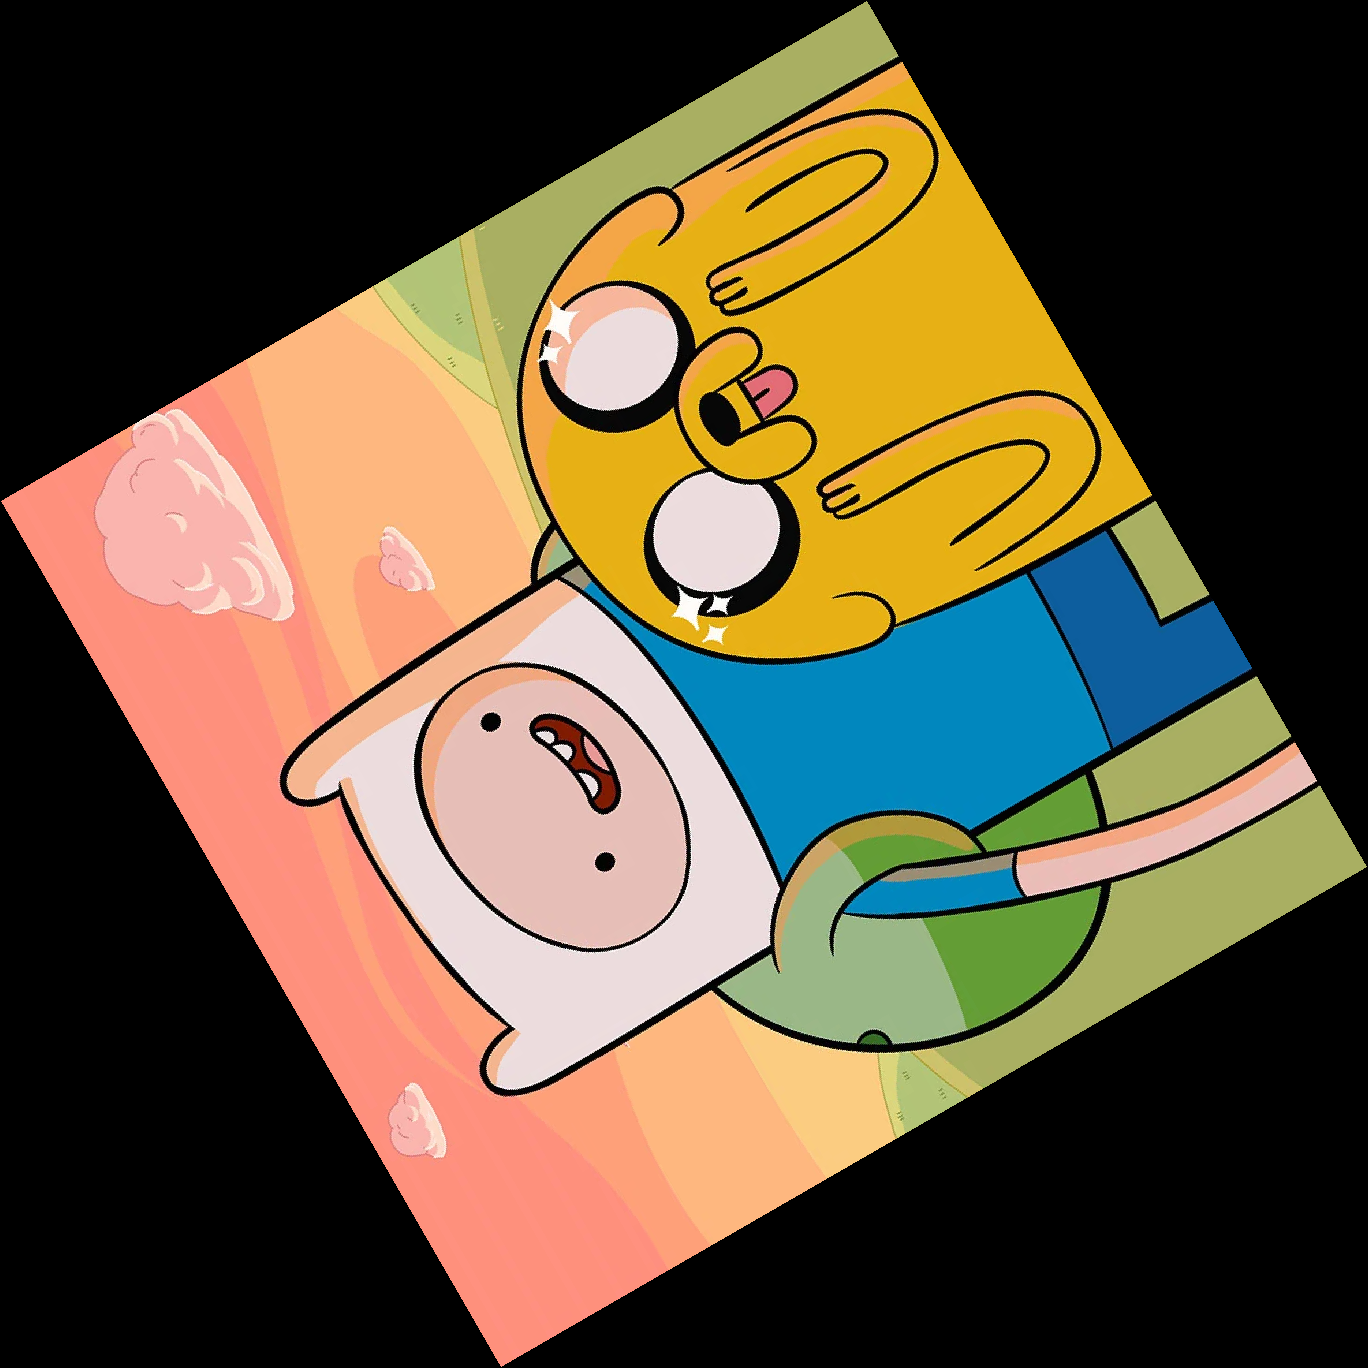

In [16]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")
print(f"Original size: {img.size}")
print(f"Rotated size: {rotated_img.size}")
rotated_img

### 3. Shear

In [18]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print(f"Original size for shear: {width} x {height}")

Original size for shear: 1000 x 1000


In [19]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor_x = 0.5
shear_factor_y = 0.0
new_width = int(width + abs(shear_factor_x) * height)
new_height = height
shear_matrix = (1, shear_factor_x, 0, 0, 1, 0)

In [31]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shear_factor = 0.5

shearx = shear_factor
sheary = 0

new_w = int(w + abs(shearx) * h)
new_h = h

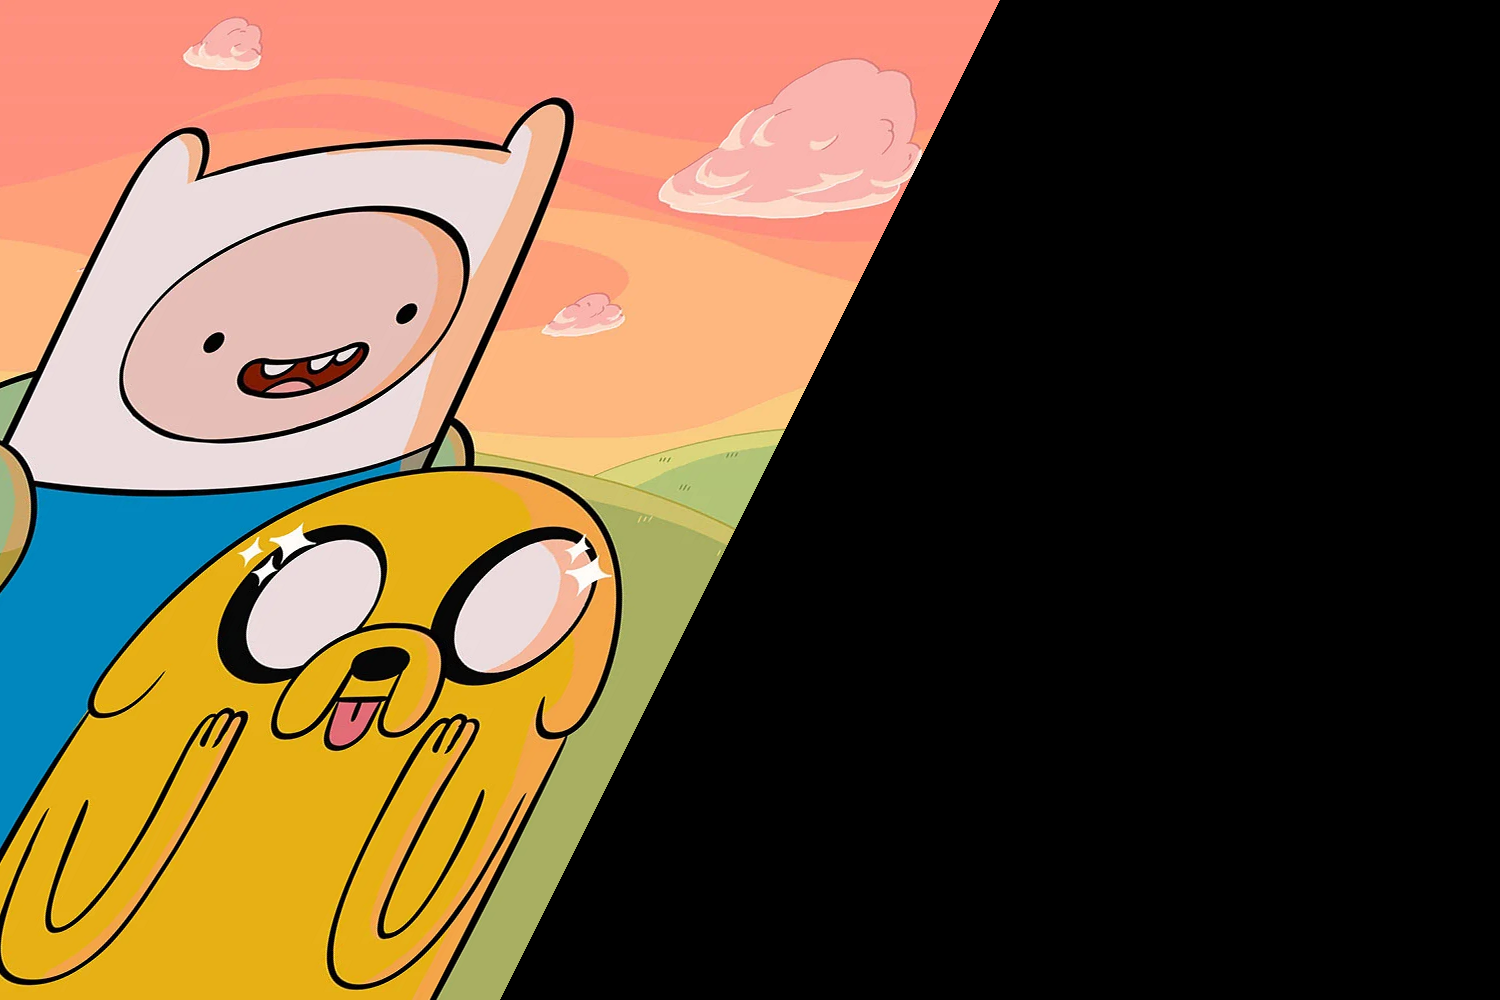

In [32]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
tx = -abs(shearx) * h if shearx < 0 else 0
ty = 0

sheared_img = img.transform(
    (new_w, new_h),
    Image.AFFINE,
    (1, shearx, tx, sheary, 1, ty),
    resample=Image.BICUBIC
)
sheared_img

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

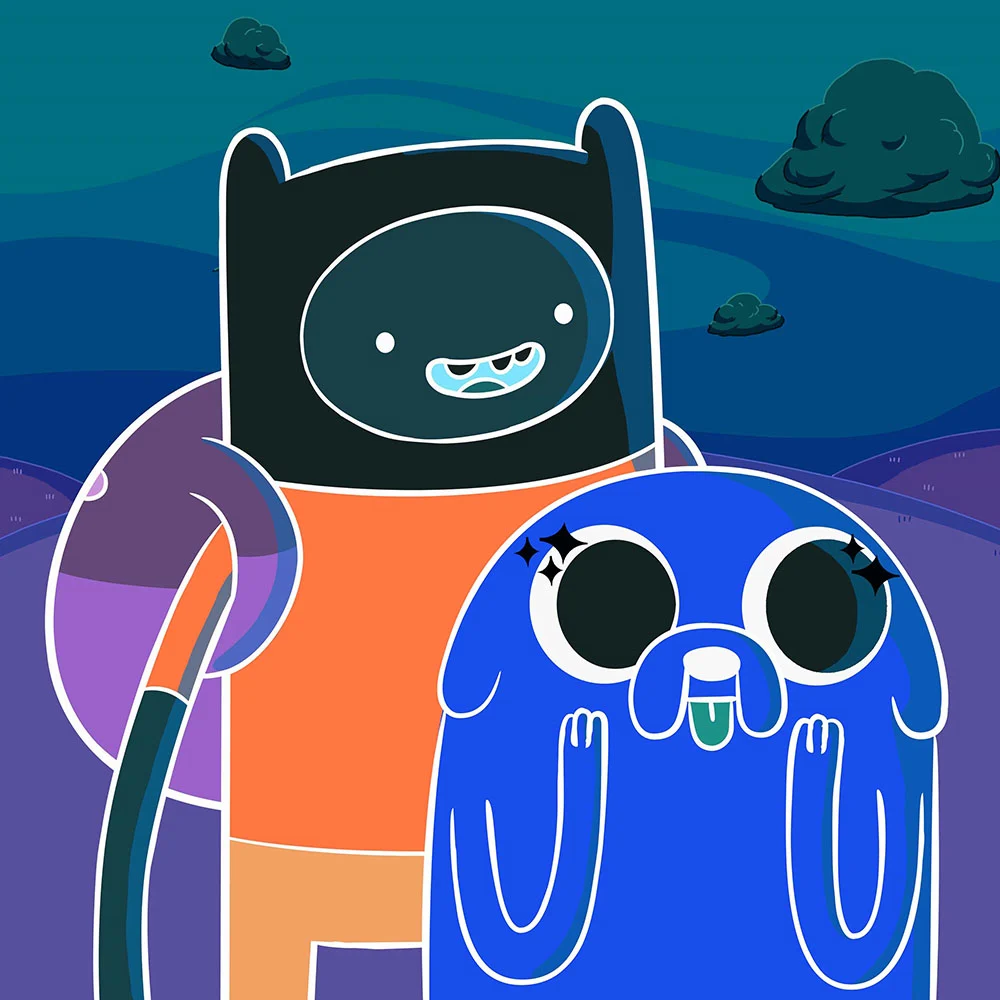

In [22]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

img_array = np.array(img)
negative_array = 255 - img_array
negative_img_np = Image.fromarray(negative_array.astype(np.uint8))
negative_img_np.save("task2_1_negative_numpy.jpg")
negative_img_np


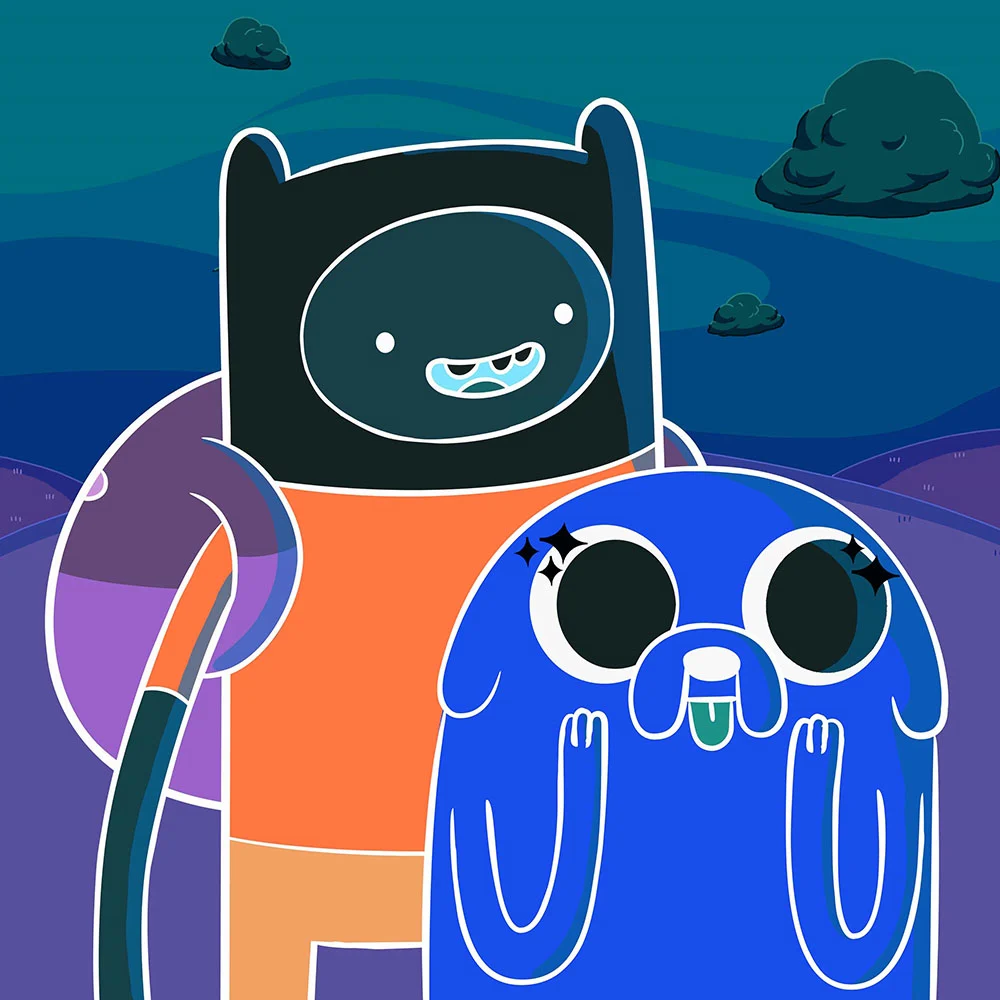

In [23]:
# Method 2: PIL's ImageOps
negative_img_ops = ImageOps.invert(img.convert("RGB"))
negative_img_ops.save("task2_1_negative_imageops.jpg")
negative_img_ops

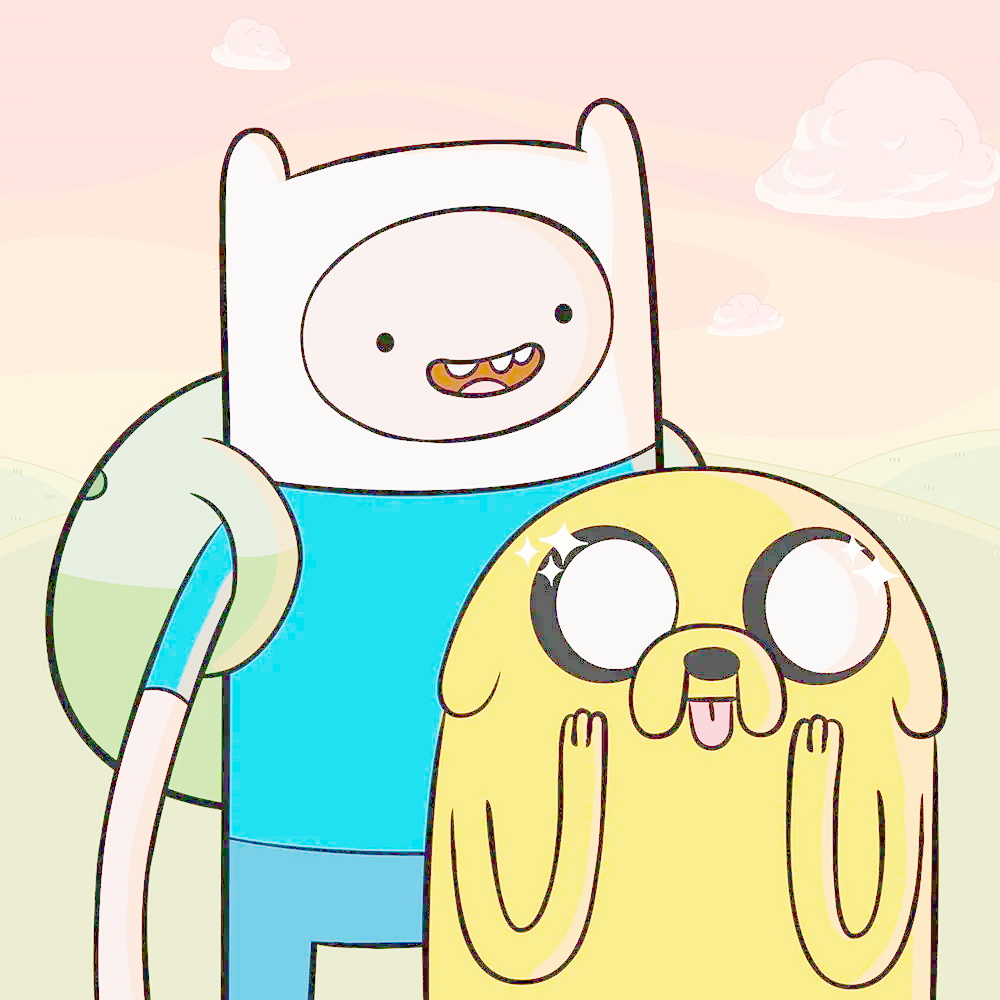

In [26]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255 / math.log(1 + 255)

# Apply the log transformation to each pixel

img_array = np.array(img, dtype=np.float64)
log_array = c * np.log(1 + img_array)
log_img = Image.fromarray(np.uint8(log_array))
log_img.save("task2_2_log.jpg")
log_img

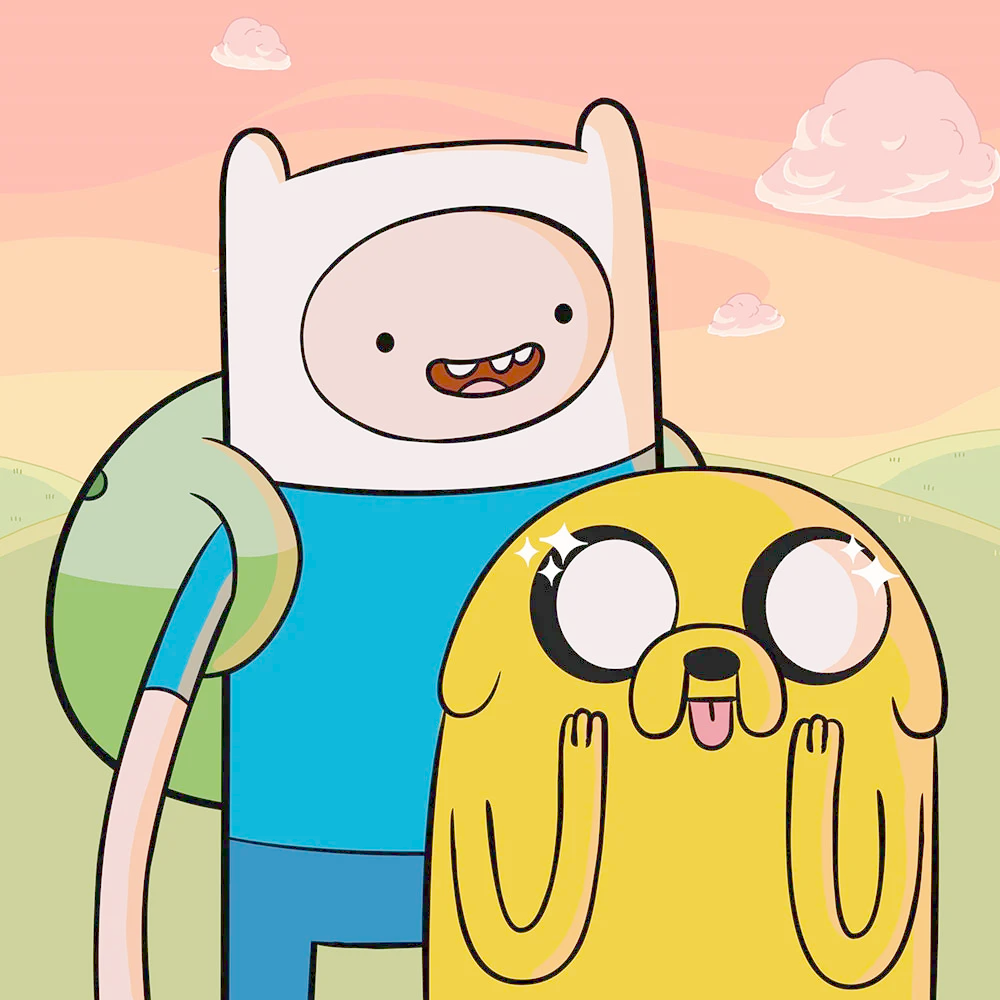

In [27]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5  # < 1 brightens the image, > 1 darkens it

img_array = np.array(img, dtype=np.float64) / 255.0
gamma_array = np.power(img_array, gamma) * 255.0
gamma_img = Image.fromarray(np.uint8(gamma_array))
gamma_img.save("task2_3_gamma.jpg")
gamma_img